In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/preprocessed-1/sdd_df_preprocessed.csv
/kaggle/input/student-depression-dataset/Student Depression Dataset.csv


In [2]:
# df = pd.read_csv('/kaggle/input/student-depression-dataset/Student Depression Dataset.csv')
df = pd.read_csv('/kaggle/input/preprocessed-1/sdd_df_preprocessed.csv')

In [3]:
df.describe(include='all')

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Is student,Sleep Duration Encoded,Suicidal Thoughts (Boolean),Family History of Mental Illness (Boolean)
count,27901.000000,27901,27901.000000,27901,27901,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901,27901,27901,27901,27901.000000,27898.000000,27901,27901.000000,27901,27901.000000,27901,27901
unique,NaN,2,NaN,52,14,NaN,NaN,NaN,NaN,NaN,5,4,28,2,NaN,NaN,2,NaN,2,NaN,2,2
top,NaN,Male,NaN,Kalyan,Student,NaN,NaN,NaN,NaN,NaN,Less than 5 hours,Unhealthy,Class 12,Yes,NaN,NaN,No,NaN,True,NaN,True,False
freq,NaN,15547,NaN,1570,27870,NaN,NaN,NaN,NaN,NaN,8310,10317,6080,17656,NaN,NaN,14398,NaN,27870,NaN,17656,14398
mean,70442.149421,NaN,25.822300,NaN,NaN,3.141214,0.000430,7.656104,2.943837,0.000681,NaN,NaN,NaN,NaN,7.156984,3.139867,NaN,0.585499,NaN,2.398050,NaN,NaN
std,40641.175216,NaN,4.905687,NaN,NaN,1.381465,0.043992,1.470707,1.361148,0.044394,NaN,NaN,NaN,NaN,3.707642,1.437347,NaN,0.492645,NaN,1.126883,NaN,NaN
min,2.000000,NaN,18.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,0.000000,NaN,1.000000,NaN,NaN
25%,35039.000000,NaN,21.000000,NaN,NaN,2.000000,0.000000,6.290000,2.000000,0.000000,NaN,NaN,NaN,NaN,4.000000,2.000000,NaN,0.000000,NaN,1.000000,NaN,NaN
50%,70684.000000,NaN,25.000000,NaN,NaN,3.000000,0.000000,7.770000,3.000000,0.000000,NaN,NaN,NaN,NaN,8.000000,3.000000,NaN,1.000000,NaN,2.000000,NaN,NaN
75%,105818.000000,NaN,30.000000,NaN,NaN,4.000000,0.000000,8.920000,4.000000,0.000000,NaN,NaN,NaN,NaN,10.000000,4.000000,NaN,1.000000,NaN,3.000000,NaN,NaN


In [4]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Is student,Sleep Duration Encoded,Suicidal Thoughts (Boolean),Family History of Mental Illness (Boolean)
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1,True,2,True,False
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0,True,2,False,True
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0,True,1,False,True
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1,True,3,True,True
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0,True,2,True,False


In [5]:
df.shape

(27901, 22)

### Checking for duplicates and null value

In [6]:
df.isna().sum()

id                                            0
Gender                                        0
Age                                           0
City                                          0
Profession                                    0
Academic Pressure                             0
Work Pressure                                 0
CGPA                                          0
Study Satisfaction                            0
Job Satisfaction                              0
Sleep Duration                                0
Dietary Habits                                0
Degree                                        0
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              3
Family History of Mental Illness              0
Depression                                    0
Is student                                    0
Sleep Duration Encoded                        0
Suicidal Thoughts (Boolean)             

In [7]:
df.duplicated().sum()

0

### Getting the standard name for the column name

In [8]:
std_name = {
    'Gender': 'gender',
    'Age': 'age',
    'City': 'city',
    'Profession': 'profession',
    'Academic Pressure': 'academic_pressure',
    'Work Pressure': 'work_pressure',
    'CGPA': 'cgpa',
    'Study Satisfaction': 'study_satisfaction',
    'Job Satisfaction': 'job_satisfaction',
    'Sleep Duration': 'sleep_duration',
    'Dietary Habits': 'dietary_habits',
    'Degree': 'degree',
    'Have you ever had suicidal thoughts ?': 'suicidal_thoughts',
    'Work/Study Hours': 'work_study_hours',
    'Financial Stress': 'financial_stress',
    'Family History of Mental Illness': 'family_history',
    'Depression': 'depression',
    'Is student': 'is_student',
    'Sleep Duration Encoded': 'sleep_duration_encoded',
    'Suicidal Thoughts (Boolean)': 'suicidal_thoughts_bool',
    'Family History of Mental Illness (Boolean)': 'family_history_bool'
}
df.rename(columns=std_name, inplace=True)

### Searching for anomaly in`city`, `profession`, `sleep_duration`, and `degree`cols

#### `city` cols

In [9]:
df.city.unique()

array(['Visakhapatnam', 'Bangalore', 'Srinagar', 'Varanasi', 'Jaipur',
       'Pune', 'Thane', 'Chennai', 'Nagpur', 'Nashik', 'Vadodara',
       'Kalyan', 'Rajkot', 'Ahmedabad', 'Kolkata', 'Mumbai', 'Lucknow',
       'Indore', 'Surat', 'Ludhiana', 'Bhopal', 'Meerut', 'Agra',
       'Ghaziabad', 'Hyderabad', 'Vasai-Virar', 'Kanpur', 'Patna',
       'Faridabad', 'Delhi', 'Saanvi', 'M.Tech', 'Bhavna', 'Less Delhi',
       'City', '3.0', 'Less than 5 Kalyan', 'Mira', 'Harsha', 'Vaanya',
       'Gaurav', 'Harsh', 'Reyansh', 'Kibara', 'Rashi', 'ME', 'M.Com',
       'Nalyan', 'Mihir', 'Nalini', 'Nandini', 'Khaziabad'], dtype=object)

In [10]:
# # checking for entries with the names that considered as a common name in India
# df.loc[(df['city']=='Bhavna') |
#        (df['city']=='Gaurav') |
#        (df['city']=='Harsha') |
#        (df['city']=='Harsh') |
#        (df['city']=='Kibara') |
#        (df['city']=='Mihir') |
#        (df['city']=='Nalini') |
#        (df['city']=='Nandini') |
#        (df['city']=='Rashi') |
#        (df['city']=='Reyansh') |
#        (df['city']=='Saanvi') |
#        (df['city']=='Vaanya') |
#        (df['city']=='Mira')]

In [11]:
# dropping entries that the value in the city col considered common name and other non-valid values
non_valid_value = ['Bhavna', 'Gaurav', 'Harsha', 'Harsh', 'Kibara', 'Mihir', 'Nalini', 'Nandini', 'Rashi', 'Reyansh', 'Saanvi', 'Vaanya', 'Mira', 'Nalyan', # common personal names
                   'City', '3.0', 'ME', 'M.Com', 'M.Tech']
for value in non_valid_value:
    df.drop(df.loc[df['city']==value].index, inplace=True)

In [12]:
df.city.value_counts()

city
Kalyan                1570
Srinagar              1372
Hyderabad             1340
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1066
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               685
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik                 547
Faridabad              461
Less Delhi               1
Less than 5 Kalyan       1
Khaziabad                1
Name: count, dtype: int64

In [13]:
df.loc[df['city']=='Less Delhi', ['city']] = 'Delhi'
df.loc[df['city']=='Less than 5 Kalyan', ['city']] = 'Kalyan'
df.loc[df['city']=='Khaziabad', ['city']] = 'Ghaziabad'

<Axes: xlabel='cgpa', ylabel='Count'>

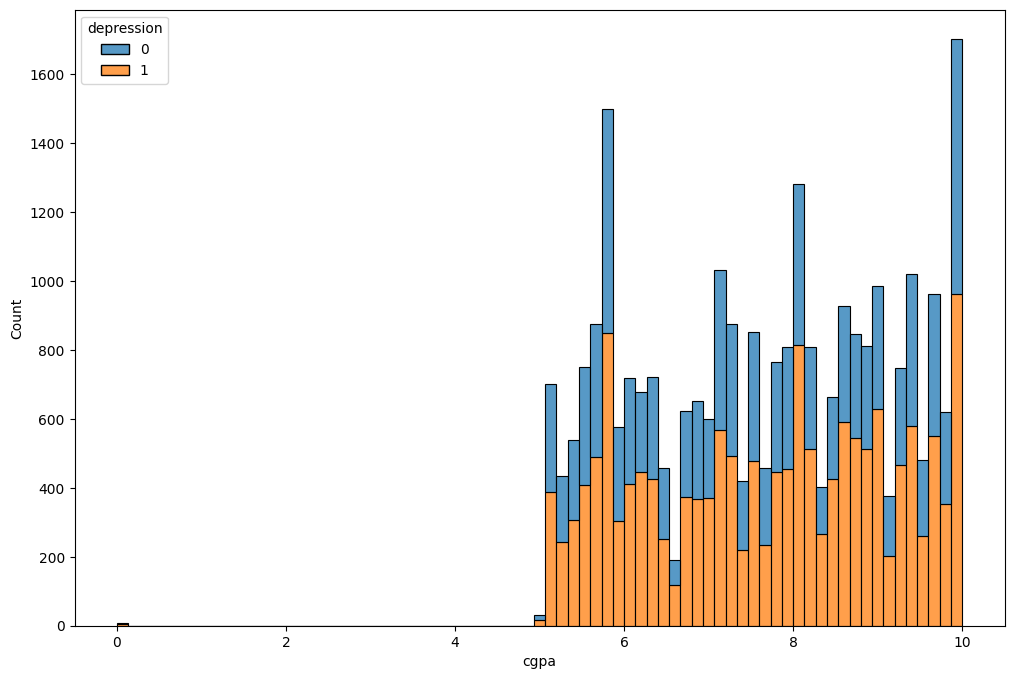

In [14]:
plt.figure(figsize=(12, 8))
sns.histplot(data=df, x='cgpa', bins=75, hue='depression', multiple='stack')

In [15]:
df.loc[df['cgpa']==0]

,id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history,depression,is_student,sleep_duration_encoded,suicidal_thoughts_bool,family_history_bool
4365,21880,Male,38.0,Chennai,Student,0.0,5.0,0.0,0.0,4.0,5-6 hours,Healthy,Class 12,No,2.0,3.0,No,0,True,2,False,False
10407,52737,Male,28.0,Vadodara,Student,3.0,0.0,0.0,4.0,0.0,Less than 5 hours,Healthy,BBA,No,12.0,2.0,No,0,True,1,False,False
11489,58062,Female,32.0,Vadodara,Student,5.0,0.0,0.0,0.0,0.0,Less than 5 hours,Unhealthy,Class 12,Yes,11.0,5.0,No,1,True,1,True,False
13909,70453,Female,20.0,Ahmedabad,Student,0.0,0.0,0.0,0.0,2.0,Less than 5 hours,Moderate,Class 12,Yes,12.0,3.0,Yes,1,True,1,True,True
14855,75007,Male,21.0,Lucknow,Student,0.0,2.0,0.0,0.0,1.0,7-8 hours,Moderate,Class 12,Yes,3.0,3.0,Yes,0,True,3,True,True
20913,105773,Male,18.0,Ahmedabad,Student,0.0,0.0,0.0,0.0,1.0,Less than 5 hours,Moderate,Class 12,Yes,9.0,5.0,No,1,True,1,True,False
21805,110097,Male,34.0,Pune,Student,1.0,0.0,0.0,5.0,0.0,Less than 5 hours,Unhealthy,M.Ed,Yes,10.0,3.0,Yes,0,True,1,True,True
25746,129756,Male,18.0,Rajkot,Student,0.0,5.0,0.0,0.0,4.0,7-8 hours,Moderate,Class 12,Yes,9.0,4.0,No,1,True,3,True,False
26719,134830,Female,24.0,Meerut,Student,0.0,0.0,0.0,0.0,2.0,More than 8 hours,Unhealthy,Class 12,No,0.0,5.0,No,0,True,4,False,False


In [16]:
# df.to_csv('sdd_df_preprocessed2.csv')

In [17]:
df.shape[0] - (df.loc[df['profession']=='Student']).shape[0]

31

In [18]:
df.loc[df['degree']=='Others']

,id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history,depression,is_student,sleep_duration_encoded,suicidal_thoughts_bool,family_history_bool
624,3227,Male,28.0,Varanasi,Student,4.0,0.0,5.66,4.0,0.0,More than 8 hours,Unhealthy,Others,Yes,10.0,5.0,Yes,1,True,4,True,True
842,4337,Male,28.0,Visakhapatnam,Student,1.0,0.0,7.94,4.0,0.0,Less than 5 hours,Unhealthy,Others,Yes,10.0,3.0,No,1,True,1,True,False
1897,9719,Female,22.0,Srinagar,Student,1.0,0.0,8.04,4.0,0.0,Less than 5 hours,Moderate,Others,No,10.0,5.0,No,0,True,1,False,False
2609,13315,Female,20.0,Bhopal,Student,5.0,0.0,5.58,2.0,0.0,7-8 hours,Moderate,Others,No,8.0,4.0,Yes,1,True,3,False,True
2928,14834,Male,27.0,Kolkata,Student,5.0,0.0,8.04,1.0,0.0,5-6 hours,Healthy,Others,No,11.0,3.0,Yes,1,True,2,False,True
3189,16067,Male,20.0,Lucknow,Student,2.0,0.0,9.36,3.0,0.0,7-8 hours,Unhealthy,Others,No,2.0,5.0,No,1,True,3,False,False
3672,18420,Male,18.0,Nashik,Student,4.0,0.0,7.47,3.0,0.0,More than 8 hours,Unhealthy,Others,Yes,11.0,4.0,No,1,True,4,True,False
4127,20659,Male,19.0,Kolkata,Student,3.0,0.0,7.53,1.0,0.0,Less than 5 hours,Moderate,Others,No,0.0,5.0,Yes,1,True,1,False,True
4427,22201,Female,22.0,Vasai-Virar,Student,4.0,0.0,6.03,3.0,0.0,5-6 hours,Healthy,Others,Yes,6.0,3.0,No,0,True,2,True,False
4516,22609,Female,23.0,Kolkata,Student,3.0,0.0,5.32,4.0,0.0,7-8 hours,Unhealthy,Others,No,7.0,4.0,Yes,1,True,3,False,True


<Axes: xlabel='work_study_hours', ylabel='Count'>

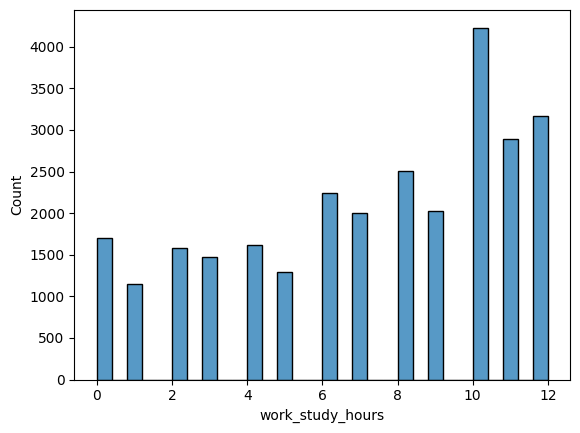

In [19]:
sns.histplot(data=df, x='work_study_hours', bins=30)

In [20]:
df.head()

,id,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history,depression,is_student,sleep_duration_encoded,suicidal_thoughts_bool,family_history_bool
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1,True,2,True,False
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0,True,2,False,True
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0,True,1,False,True
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1,True,3,True,True
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0,True,2,True,False


In [21]:
# dropping the entries that are not student in the profession columns and dropping the profession, is_student, work_pressure, and job_satisfaction columns
df.drop(df.loc[df['profession']!='Student'].index, inplace=True)
df.drop(['profession'], axis=1, inplace=True)
df.drop(['job_satisfaction'], axis=1, inplace=True)
df.drop(['work_pressure'], axis=1, inplace=True)

In [22]:
# dropping the other values from the sleep_duration, dietary_habits, degree
df.drop(df.loc[df['sleep_duration']=='Others'].index, inplace=True)
df.drop(df.loc[df['dietary_habits']=='Others'].index, inplace=True)
df.drop(df.loc[df['degree']=='Others'].index, inplace=True)

In [23]:
# dropping the entries with the value in cgpa columns is zero
df.drop(df.loc[df['cgpa']==0].index, inplace=True)

In [24]:
# dropping the id columns cause dont impact prediction
df.drop(['id'], axis=1, inplace=True)

In [25]:
df.isnull().sum()

gender                    0
age                       0
city                      0
academic_pressure         0
cgpa                      0
study_satisfaction        0
sleep_duration            0
dietary_habits            0
degree                    0
suicidal_thoughts         0
work_study_hours          0
financial_stress          3
family_history            0
depression                0
is_student                0
sleep_duration_encoded    0
suicidal_thoughts_bool    0
family_history_bool       0
dtype: int64

In [26]:
# dropping the 3 null value from all the datasets
df.drop(df.loc[df.financial_stress.isnull()].index, axis=0, inplace=True)

### talking about the age columns, observing for any behaviour

In [27]:
df.age.describe()

count    27770.000000
mean        25.818725
std          4.906682
min         18.000000
25%         21.000000
50%         25.000000
75%         30.000000
max         59.000000
Name: age, dtype: float64

In [28]:
print(df.loc[df['age']>36].shape)
print(df.loc[df['age']>35].shape)
print(df.loc[df['age']>34].shape)
print(df.loc[df['age']>33].shape)

(31, 18)
(38, 18)
(48, 18)
(1509, 18)


Starting from >34, the number of entries is extremely decreasing 

In [29]:
df = df.loc[df['age']<=34]

<Axes: xlabel='age', ylabel='Count'>

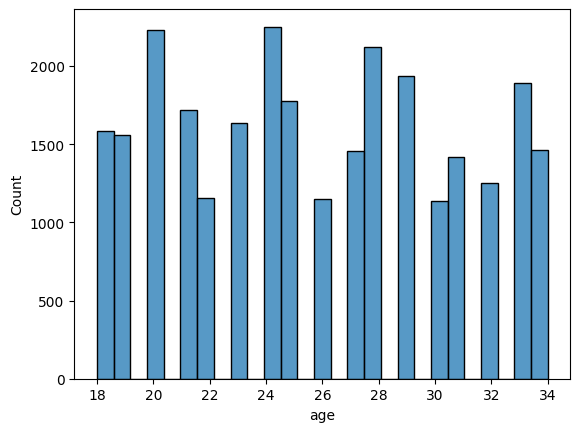

In [30]:
sns.histplot(data=df.loc[df['age']<=36], x='age')

In [31]:
# df.loc[df['age']>35]

to be the next plan for next preprocessing for this column

In [32]:
df.head()

,gender,age,city,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,work_study_hours,financial_stress,family_history,depression,is_student,sleep_duration_encoded,suicidal_thoughts_bool,family_history_bool
0,Male,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1,True,2,True,False
1,Female,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0,True,2,False,True
2,Male,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0,True,1,False,True
3,Female,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1,True,3,True,True
4,Female,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0,True,2,True,False


In [33]:
df.shape

(27722, 18)

In [34]:
df.to_csv('preprocessed-2.csv')

--------------

In [35]:
df.degree.value_counts()

degree
Class 12    6056
B.Ed        1856
B.Com       1501
B.Arch      1473
BCA         1428
MSc         1181
B.Tech      1151
MCA         1036
M.Tech      1018
BHM          920
BSc          879
M.Ed         815
B.Pharm      808
M.Com        730
BBA          694
MBBS         689
LLB          668
BE           609
BA           594
M.Pharm      579
MD           566
MBA          560
MA           542
PhD          514
LLM          480
MHM          191
ME           184
Name: count, dtype: int64

<Axes: xlabel='degree', ylabel='Count'>

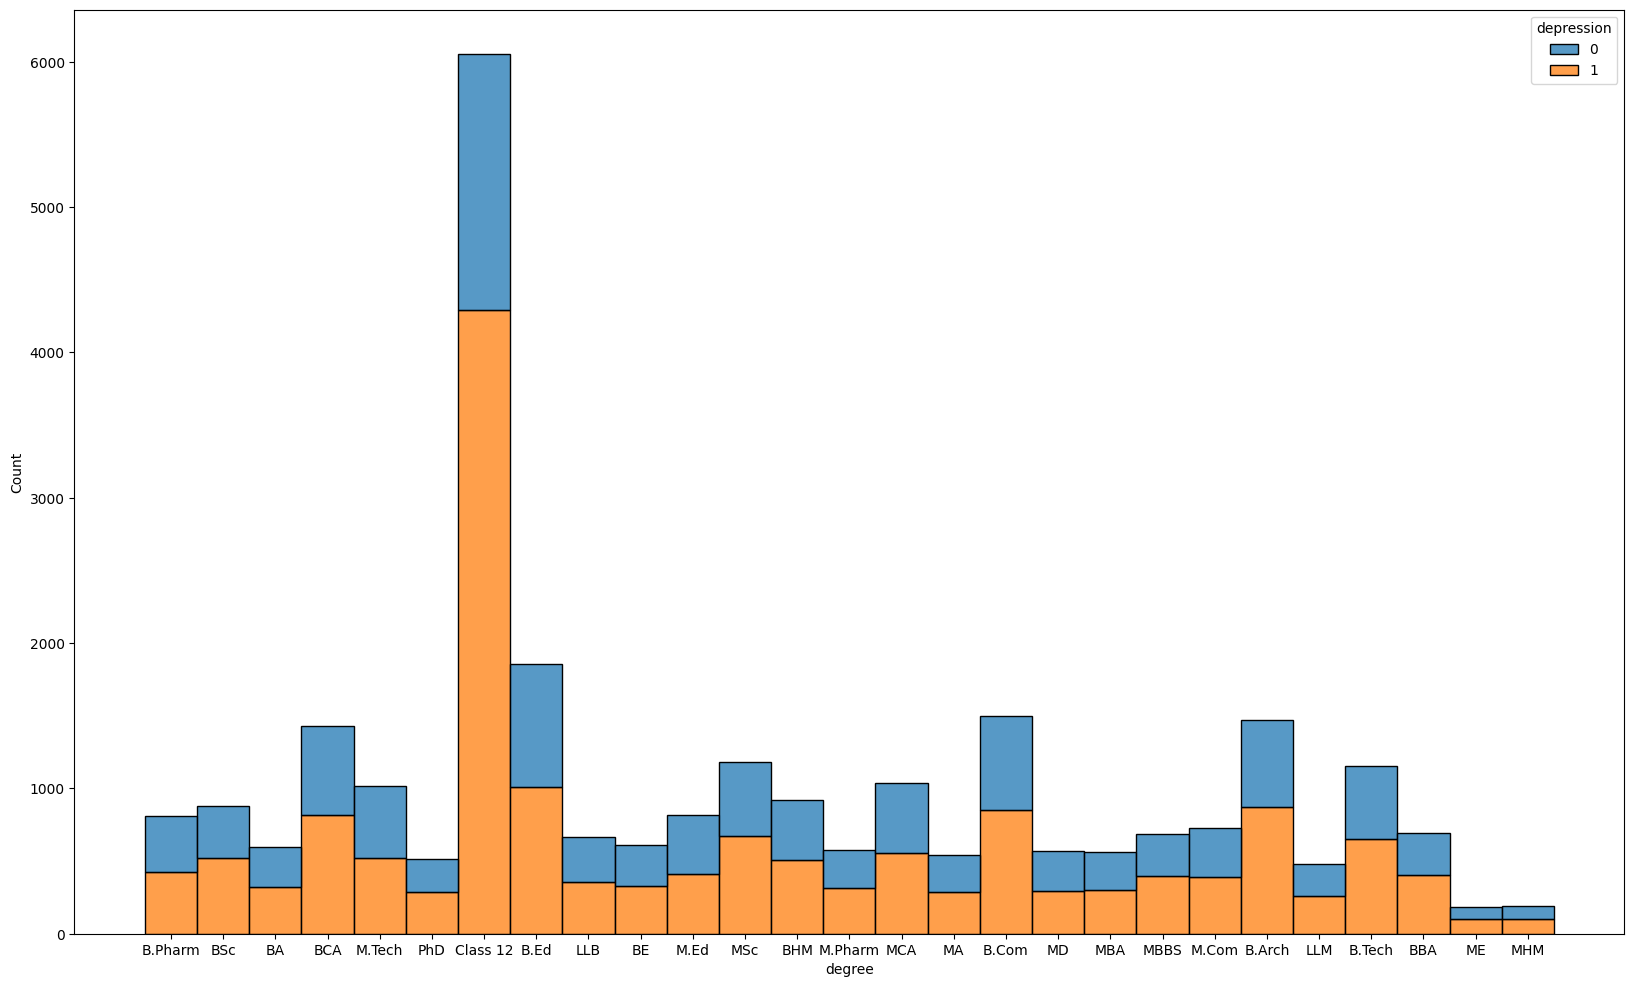

In [36]:
plt.figure(figsize=(20, 12))
sns.histplot(data=df, x='degree', hue='depression', multiple='stack')

In [37]:
df['is_class12'] = df['degree'].apply(lambda x: 'yes' if x=='Class 12' else 'no')

<Axes: xlabel='is_class12', ylabel='Count'>

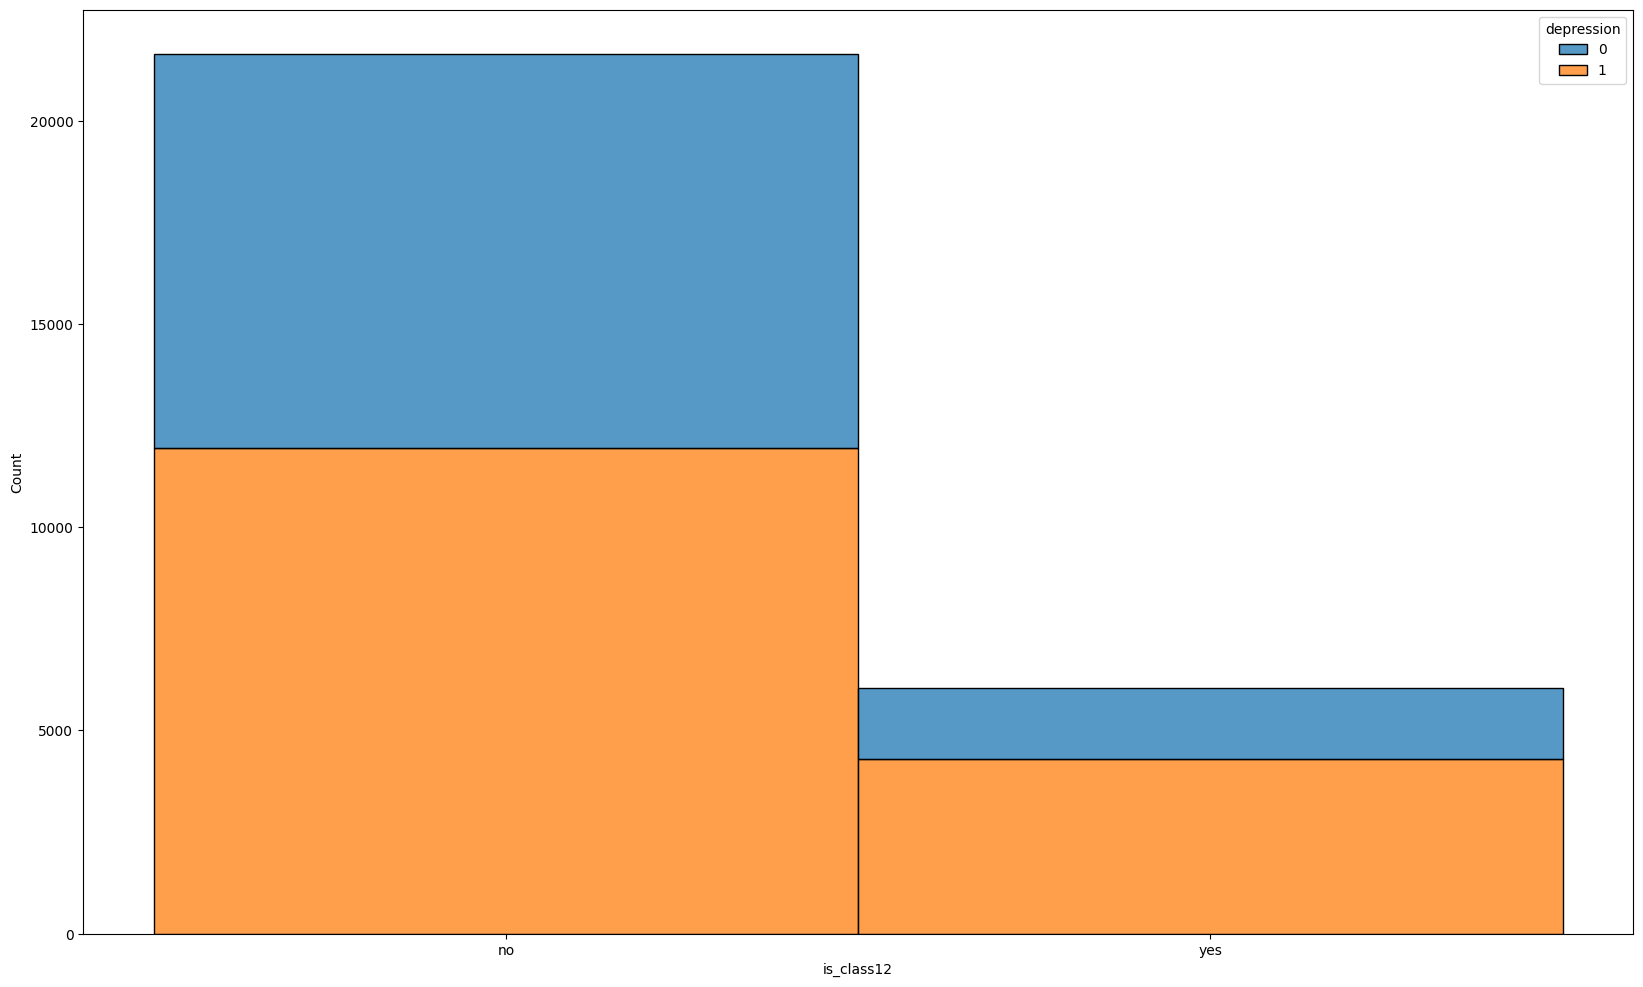

In [38]:
plt.figure(figsize=(20, 12))
sns.histplot(data=df, x='is_class12', hue='depression', multiple='stack')

In [39]:
def s_berapa(x):
    if x=='Class 12':
        return 0
    elif x[0] == 'B':
        return 1
    elif x[0] == 'M':
        return 2
    elif x=='LLM':
        return 2
    elif x=='LLB':
        return 1
    else:
        return 0

df['no_degree'] = df['degree'].apply(s_berapa)

In [40]:
df.no_degree.value_counts()

no_degree
1    12581
2     8571
0     6570
Name: count, dtype: int64

<Axes: xlabel='no_degree', ylabel='count'>

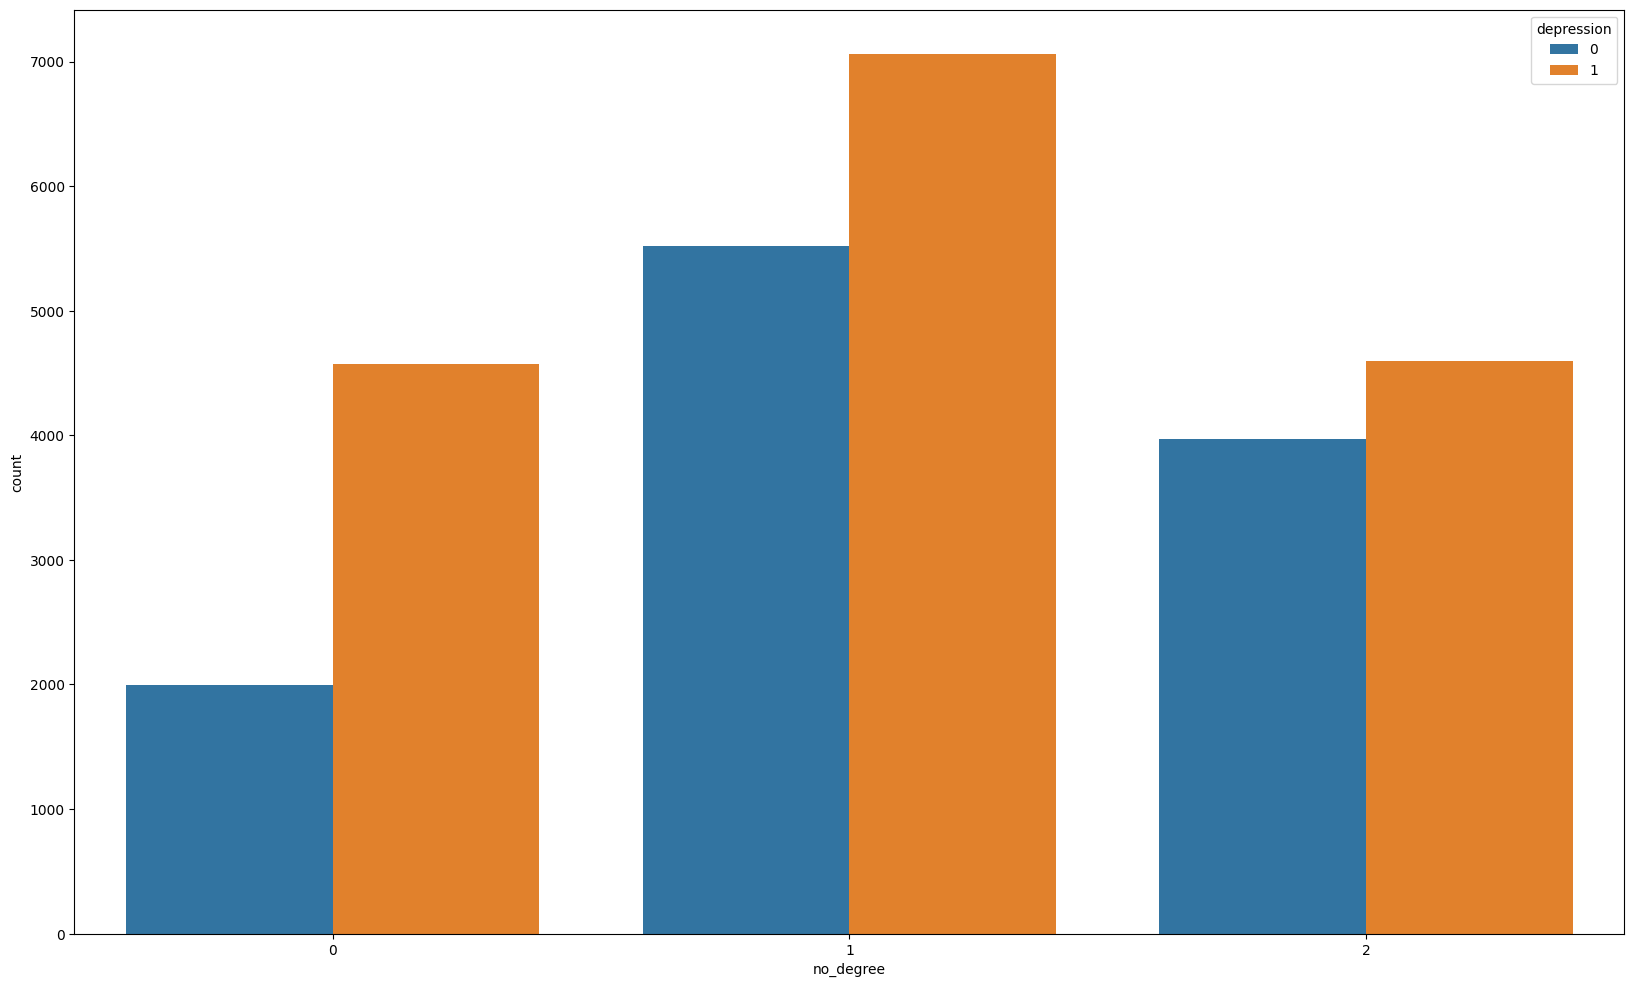

In [41]:
plt.figure(figsize=(20, 12))
sns.countplot(data=df, x='no_degree', hue='depression')

------------

In [42]:
df.loc[df['age']>34].shape

(0, 20)

<Axes: xlabel='age', ylabel='count'>

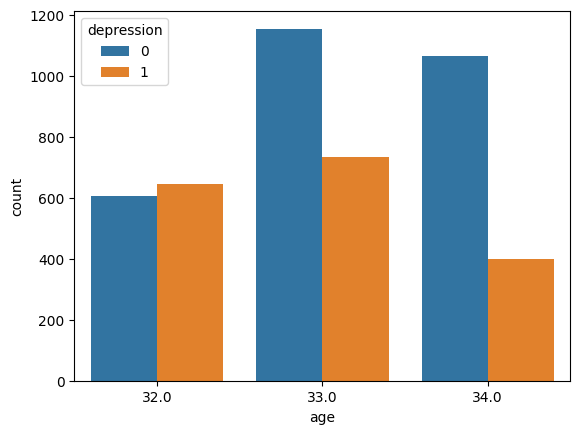

In [43]:
sns.countplot(df.loc[df['age']>31], x='age', hue='depression')

<Axes: xlabel='age', ylabel='Count'>

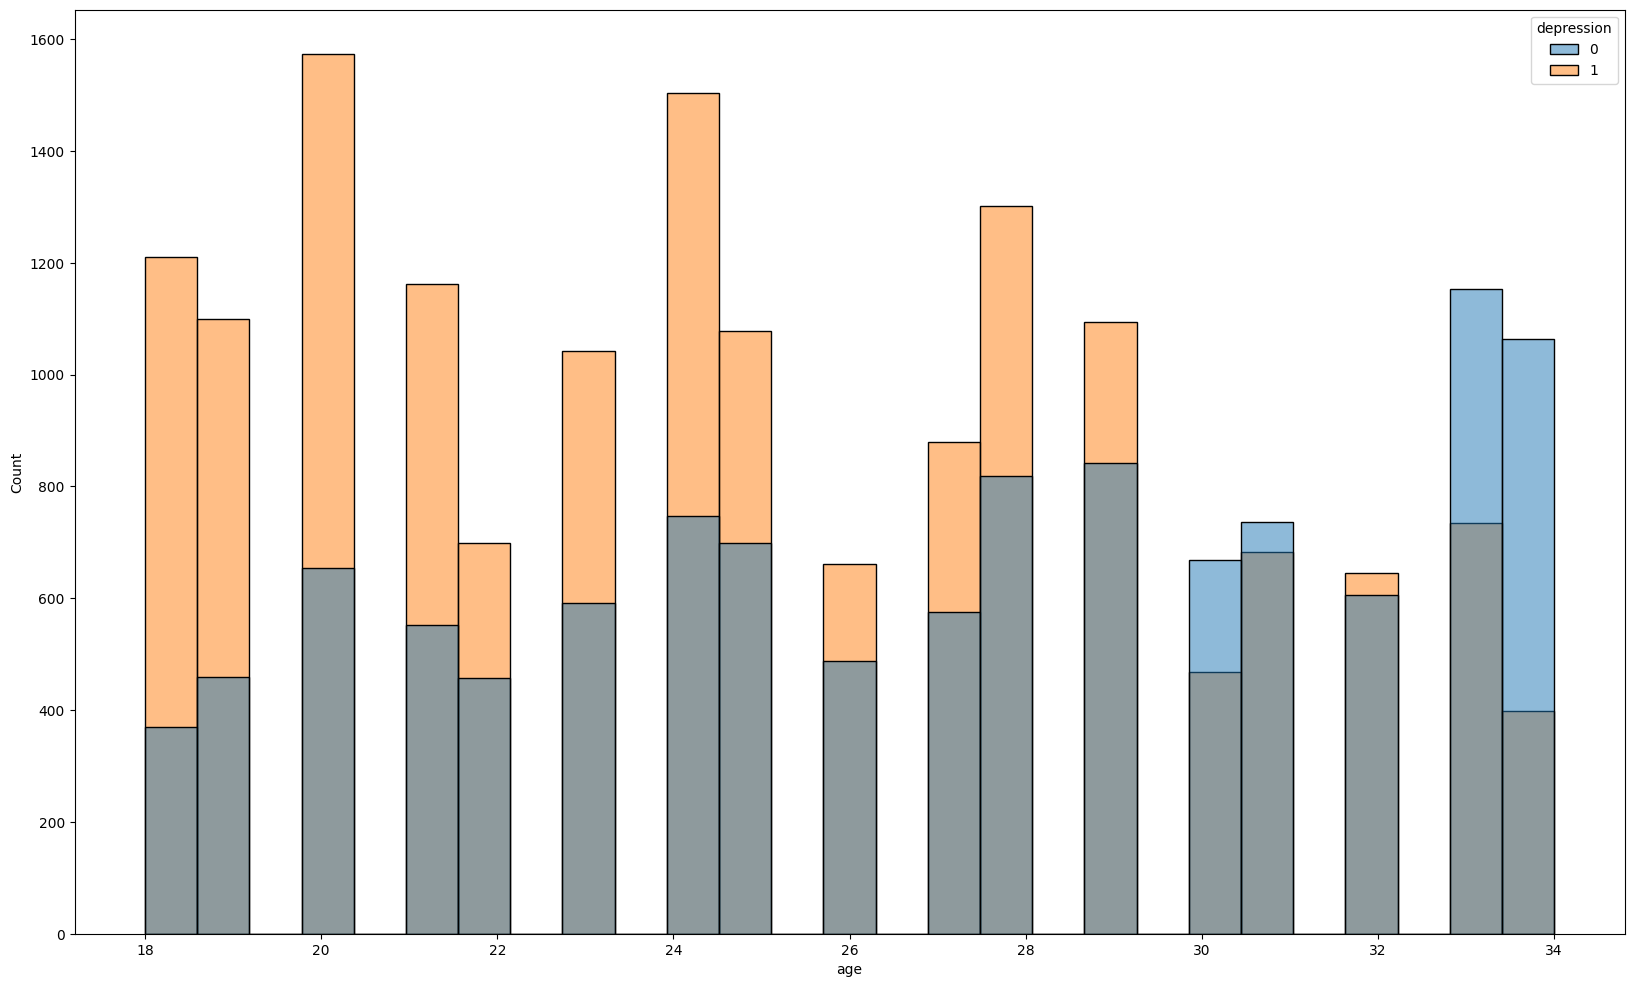

In [44]:
plt.figure(figsize=(20, 12))
sns.histplot(data=df, x='age', hue='depression')
# df.age.describe()